In [5]:
import pandas as pd
import numpy as np
import os
from glob import glob
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [3]:
df_raw = pd.read_csv("edge_features_abs.csv")
df_z = pd.read_csv("edge_features_z.csv")

feature_names = df_raw.drop(columns=["Subject", "Label"]).columns

X_raw = df_raw.drop(columns=["Subject", "Label"]).values
X_z = df_z.drop(columns=["Subject", "Label"]).values

y = df_raw["Label"].values

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

K = 30

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)
cv_splits = list(cv.split(X_raw, y))

edge_frequency = np.zeros(X_raw.shape[1], dtype=int)

fold_accuracies = []
all_importances = []
for fold, (train_idx, test_idx) in enumerate(cv_splits,start=1):
    X_train_raw = X_raw[train_idx]
    X_test_raw = X_raw[test_idx]

    X_train_z = X_z[train_idx]
    X_test_z = X_z[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    class0 = (y_train == 0)
    class1 = (y_train == 1)

    mwu_scores = []
    for f in range(X_raw.shape[1]):
        group0 = X_train_raw[class0, f]
        group1 = X_train_raw[class1, f]

        _, p_value = mannwhitneyu(group0, group1, alternative="two-sided")
        score = -np.log10(p_value + 1e-10)
        mwu_scores.append(score)

    mwu_scores = np.array(mwu_scores)

    ranked_features = np.argsort(mwu_scores)[::-1]
    top_features = ranked_features[:K]
    fold_mwu_results = pd.DataFrame({
        "Rank": np.arange(1, K + 1),
        "Feature_Name": feature_names[top_features],
        "MWU_Score": mwu_scores[top_features]
    })
    fold_mwu_results.to_csv(f"mannk30/fold_{fold}_top30_edges.csv", index=False)
    edge_frequency[top_features] += 1

    X_train_selected = X_train_z[:, top_features]
    X_test_selected = X_test_z[:, top_features]

    rf = RandomForestClassifier(n_estimators=90, max_features=5, random_state=42)
    rf.fit(X_train_selected, y_train)

    fold_importance = pd.DataFrame({
        "Feature_Name": feature_names[top_features],
        "Importance": rf.feature_importances_,
        "Fold": fold
    })
    all_importances.append(fold_importance)

    y_pred = rf.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    print(f"\nFold {fold}, Accuracy={acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

threshold = 25

stable_edges = pd.DataFrame({
    "Feature_Name": feature_names,
    "Frequency": edge_frequency
})
stable_edges = stable_edges[stable_edges["Frequency"] > threshold]
all_importances = pd.concat(all_importances,ignore_index=True)
mean_importance = (all_importances.groupby("Feature_Name")["Importance"].mean().reset_index())
stable_edges = stable_edges.merge(mean_importance,on="Feature_Name",how="left")
stable_edges = stable_edges.sort_values(by=["Frequency", "Importance"], ascending=False) 
stable_edges.to_csv("stable_edges_k30.csv", index=False)

print("\nMean Accuracy:", np.mean(fold_accuracies))
print("\nStable edges:")
print(stable_edges)


Fold 1, Accuracy=0.6667
              precision    recall  f1-score   support

          AD     0.6667    0.5714    0.6154         7
          CN     0.6667    0.7500    0.7059         8

    accuracy                         0.6667        15
   macro avg     0.6667    0.6607    0.6606        15
weighted avg     0.6667    0.6667    0.6637        15


Fold 2, Accuracy=0.5714
              precision    recall  f1-score   support

          AD     0.5000    0.3333    0.4000         6
          CN     0.6000    0.7500    0.6667         8

    accuracy                         0.5714        14
   macro avg     0.5500    0.5417    0.5333        14
weighted avg     0.5571    0.5714    0.5524        14


Fold 3, Accuracy=0.5714
              precision    recall  f1-score   support

          AD     0.5000    0.3333    0.4000         6
          CN     0.6000    0.7500    0.6667         8

    accuracy                         0.5714        14
   macro avg     0.5500    0.5417    0.5333        14

/var/folders/x_/8wrzcx450cl3npkt6_nclhk00000gn/T/ipykernel_63768/172624486.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


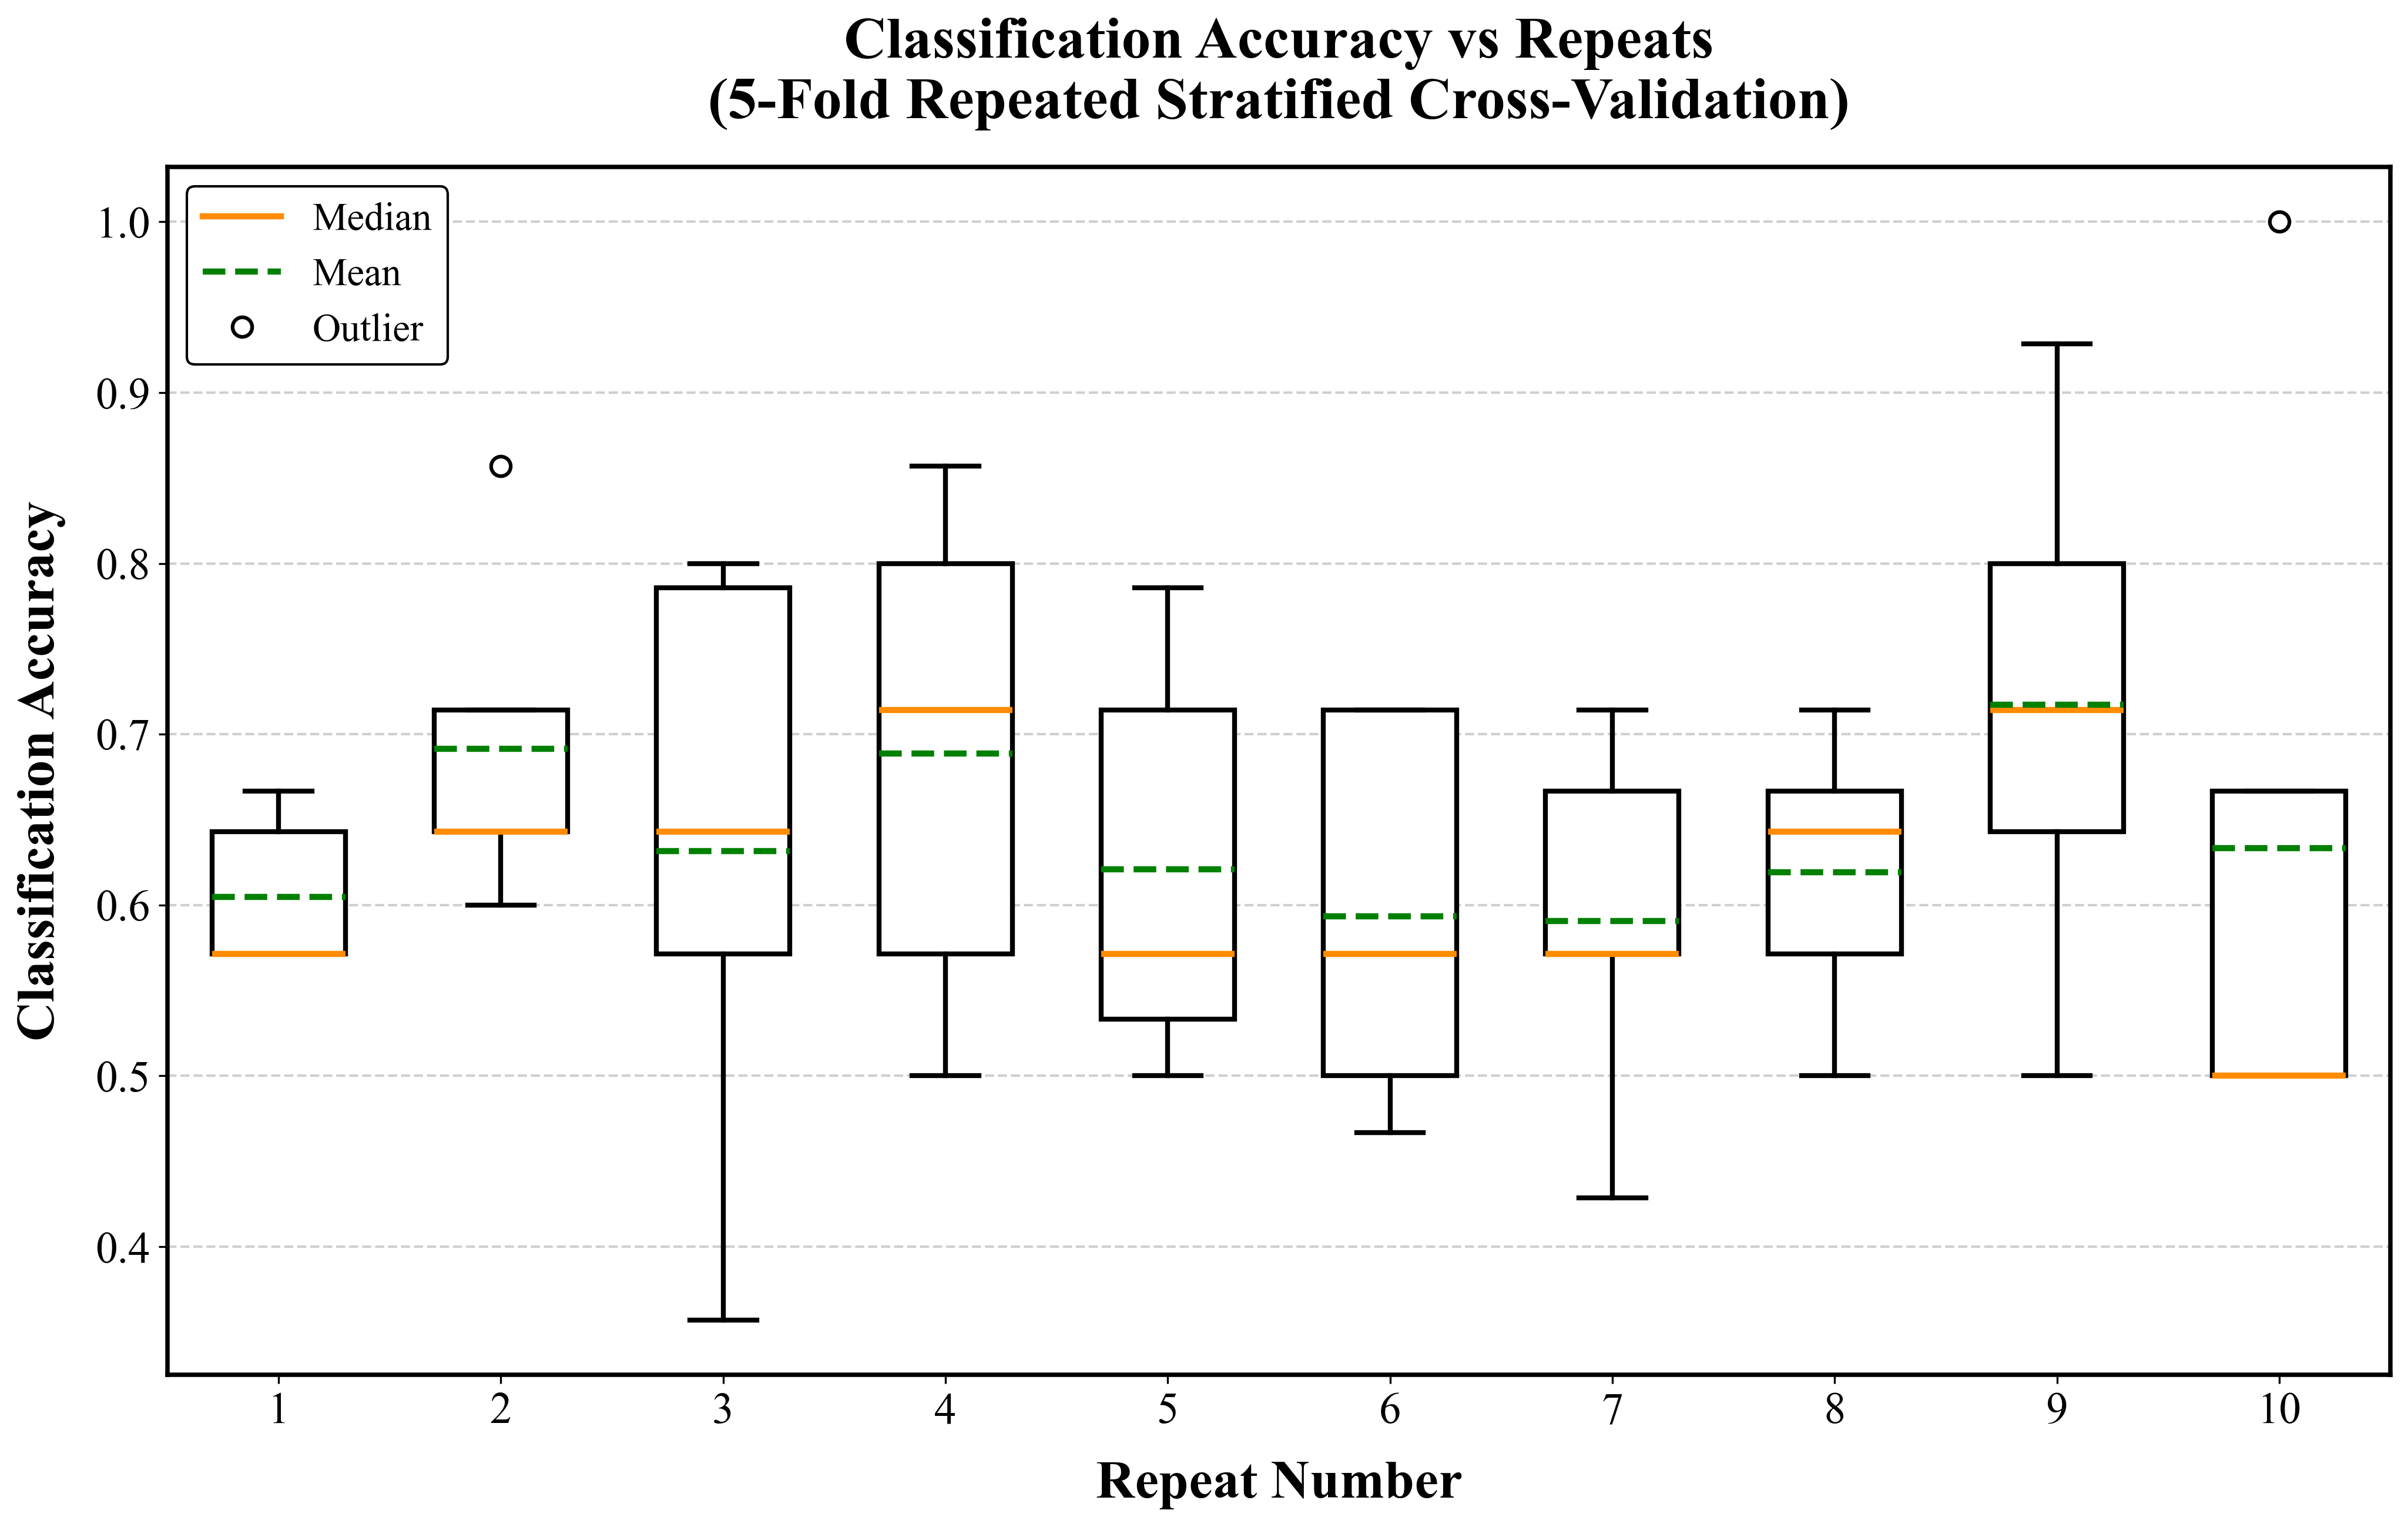

In [7]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "axes.linewidth": 1.8
})

n_splits = 5
n_repeats = 10
acc_array = np.array(fold_accuracies)
acc_matrix = acc_array.reshape(n_repeats, n_splits)

fig, ax = plt.subplots(figsize=(14, 9),dpi=300)

box = ax.boxplot(
    acc_matrix.T,
    labels=[f"{i+1}" for i in range(n_repeats)],
    patch_artist=True,
    showmeans=True,
    meanline=True,
    widths=0.6,
    boxprops=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=2
    ),
    whiskerprops=dict(
        color="black",
        linewidth=2
    ),
    capprops=dict(
        color="black",
        linewidth=2
    ),
    medianprops=dict(
        color="darkorange",
        linewidth=2.5
    ),
    meanprops=dict(
        color="green",
        linestyle="--",
        linewidth=2.5
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8,
        markeredgewidth=1.5
    )
)

ax.set_xlabel("Repeat Number", fontweight="bold", labelpad=12)
ax.set_ylabel("Classification Accuracy", fontweight="bold", labelpad=12)
ax.set_title("Classification Accuracy vs Repeats\n" "(5-Fold Repeated Stratified Cross-Validation)", fontweight="bold", pad=20)
ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.6)

legend_elements = [
    Line2D(
        [0], [0],
        color="darkorange",
        linewidth=2.5,
        label="Median"
    ),
    Line2D(
        [0], [0],
        color="green",
        linestyle="--",
        linewidth=2.5,
        label="Mean"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        markersize=8,
        label="Outlier"
    )
]
ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1
)

plt.tight_layout()
plt.savefig("./results/classification_accuracy_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()